# Обучение ML-пайплайна — Knowledge Tracing (ASSISTments 2009)

Этот ноутбук — **главный файл для обучения**. Он по шагам прогоняет весь пайплайн
(ETL → 4 модели → оценка → графики) и в конце даёт запуск всего одной командой.

**Где запускать:**
* **Локально** — открыть из корня проекта (`jupyter lab`), ядро = окружение с `requirements.txt`.
* **Google Colab / Kaggle** — раскомментировать ячейку установки ниже (там есть бесплатный GPU,
  на нём DKT/Optuna обучаются заметно быстрее).

**Режимы данных:** `sample` (быстро, офлайн, по умолчанию) или `full` (полный ASSISTments,
скачивается автоматически) — для **окончательного обучения** используйте `full`.

In [2]:
# === Только для Google Colab / Kaggle (локально не нужно) ===
# !git clone https://github.com/<ваш-логин>/<имя-репо>.git
# %cd <имя-репо>
# !pip install -r requirements.txt

In [3]:
import os
from pathlib import Path

# перейти в корень проекта (папка, где лежит config/config.yaml)
root = Path.cwd()
while not (root / 'config' / 'config.yaml').exists() and root != root.parent:
    root = root.parent
os.chdir(root)
print('project root:', root)

from src.utils import load_config
cfg = load_config('config/config.yaml')

DATA_SOURCE = 'sample'   # 'sample' (быстро) или 'full' (окончательное обучение)
cfg['data'] and print('config loaded')

project root: /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing
config loaded


## 1. ETL — Extract · Transform · Load

In [4]:
from src.etl.extract import extract
from src.etl.transform import transform, build_sequences
from src.etl.load import load

df_raw = extract(cfg, data_source=DATA_SOURCE)
processed = transform(df_raw, cfg)
load(processed, cfg)

print(processed.stats)
processed.features.head()

13:36:00 | INFO    | kt-pipeline | Loading committed sample dataset: /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/data/sample/assistments_sample.csv
13:36:00 | INFO    | kt-pipeline | Transform complete: {'n_interactions': 34542, 'n_students': 288, 'n_skills': 90, 'global_correct_rate': 0.6648, 'split_students': {'train': 201, 'val': 29, 'test': 58}, 'split_interactions': {'train': 23943, 'val': 3343, 'test': 7256}}
13:36:00 | INFO    | kt-pipeline | Loaded processed artifacts into /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/data/processed


{'n_interactions': 34542, 'n_students': 288, 'n_skills': 90, 'global_correct_rate': 0.6648, 'split_students': {'train': 201, 'val': 29, 'test': 58}, 'split_interactions': {'train': 23943, 'val': 3343, 'test': 7256}}


,user_id,split,correct,skill_idx,order_idx,user_prior_attempts,user_prior_correct_rate,skill_prior_attempts,skill_prior_correct_rate,recent3_correct_rate,skill_difficulty
0,0,test,0,0,0,0,0.664787,0,0.664787,0.664787,0.266409
1,0,test,1,0,1,1,0.000000,1,0.000000,0.000000,0.266409
2,0,test,1,0,2,2,0.500000,2,0.500000,0.500000,0.266409
3,0,test,1,0,3,3,0.666667,3,0.666667,0.666667,0.266409
4,0,test,0,0,4,4,0.750000,4,0.750000,1.000000,0.266409


## 2. Контроль качества данных и дрейф

In [5]:
from src.monitoring.data_quality import quality_report
from src.monitoring.drift import drift_report

print('data quality:', quality_report(processed.long)['passed'])

ref = processed.features[processed.features['split'] == 'train']
cur = processed.features[processed.features['split'] == 'test']
drift = drift_report(ref, cur, processed.feature_cols, cfg)
print('drift status:', drift['overall_status'])

data quality: True
drift status: OK


## 3. Обучение моделей
BKT (baseline) · DKT (LSTM) · DKT+Optuna (авто-HPO) · AutoML (FLAML).

In [6]:
train_seq = build_sequences(processed.long, 'train')
val_seq   = build_sequences(processed.long, 'val')
test_seq  = build_sequences(processed.long, 'test')
n_skills  = processed.n_skills
results, preds = {}, {}

In [7]:
from src.models import bkt as bkt_mod
from src.evaluation.metrics import compute_metrics

bkt_params = bkt_mod.fit_bkt_per_skill(train_seq, n_skills, cfg['models']['bkt']['em_iters'])
_, _, _, yt, yp = bkt_mod.evaluate_bkt(bkt_params, test_seq, n_skills)
results['BKT'], preds['BKT'] = compute_metrics(yt, yp), (yt, yp)
results['BKT']

{'auc': 0.7075931344817477,
 'accuracy': 0.7283627342888643,
 'f1': 0.8204754531378086,
 'precision': 0.7489191885600266,
 'recall': 0.9071500503524673,
 'rmse': 0.4340718009425276,
 'log_loss': 0.5620329674561167,
 'n': 7256}

In [8]:
from src.models import dkt as dkt_mod

device = dkt_mod.pick_device()
train_tr = dkt_mod.traces_from_sequences(train_seq)
val_tr   = dkt_mod.traces_from_sequences(val_seq)
test_tr  = dkt_mod.traces_from_sequences(test_seq)
d = cfg['models']['dkt']
dkt_model, losses = dkt_mod.train_dkt(train_tr, n_skills, device=device,
    embed_dim=d['embed_dim'], hidden_dim=d['hidden_dim'], dropout=d['dropout'],
    epochs=d['epochs'], batch_size=d['batch_size'], lr=d['lr'], verbose=True)
_, _, _, yt, yp = dkt_mod.evaluate_dkt(dkt_model, test_tr, device)
results['DKT'], preds['DKT'] = compute_metrics(yt, yp), (yt, yp)
results['DKT']

[DKT] epoch  5/15 loss=0.5040
[DKT] epoch 10/15 loss=0.4676
[DKT] epoch 15/15 loss=0.4414


{'auc': 0.7782120031284254,
 'accuracy': 0.7597943873298139,
 'f1': 0.8408065555657859,
 'precision': 0.7697235333782873,
 'recall': 0.9263542300669507,
 'rmse': 0.4062502554112466,
 'log_loss': 0.49583396944269403,
 'n': 7198}

In [9]:
from src.models.dkt_optuna import search_dkt

o = cfg['models']['dkt_optuna']
search = search_dkt(train_tr, val_tr, n_skills, n_trials=o['n_trials'], epochs_per_trial=o['epochs_per_trial'])
b = search['best_params']; print('best:', b)
best_model, _ = dkt_mod.train_dkt(train_tr, n_skills, device=device,
    embed_dim=b['embed_dim'], hidden_dim=b['hidden_dim'], dropout=b['dropout'],
    lr=b['lr'], batch_size=b['batch_size'], epochs=d['epochs'])
_, _, _, yt, yp = dkt_mod.evaluate_dkt(best_model, test_tr, device)
results['DKT+Optuna'], preds['DKT+Optuna'] = compute_metrics(yt, yp), (yt, yp)
results['DKT+Optuna']

/Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
13:36:25 | INFO    | kt-pipeline | Optuna best val AUC=0.7727 params={'embed_dim': 128, 'hidden_dim': 128, 'dropout': 0.12464611457443747, 'lr': 0.0034191684117658946, 'batch_size': 16}


best: {'embed_dim': 128, 'hidden_dim': 128, 'dropout': 0.12464611457443747, 'lr': 0.0034191684117658946, 'batch_size': 16}


{'auc': 0.7584699649970077,
 'accuracy': 0.7429841622672965,
 'f1': 0.8260297160052661,
 'precision': 0.7698510078878177,
 'recall': 0.8910529519172246,
 'rmse': 0.4193932070152748,
 'log_loss': 0.5285596104988928,
 'n': 7198}

In [10]:
from src.models.automl_flaml import train_automl, evaluate_automl

Xtr, ytr = processed.split_xy('train')
Xva, yva = processed.split_xy('val')
Xte, yte = processed.split_xy('test')
a = cfg['models']['automl_flaml']
automl = train_automl(Xtr, ytr, Xva, yva, time_budget_s=a['time_budget_s'],
    metric=a['metric'], estimator_list=a['estimator_list'])
_, _, _, yt, yp = evaluate_automl(automl, Xte, yte)
results['AutoML'], preds['AutoML'] = compute_metrics(yt, yp), (yt, yp)
print('AutoML выбрал:', automl.best_estimator)
results['AutoML']

13:37:32 | INFO    | kt-pipeline | FLAML best estimator=xgboost | config={'n_estimators': 43, 'max_leaves': 59, 'min_child_weight': np.float64(0.5328687178354117), 'learning_rate': np.float64(0.13211747397711632), 'subsample': np.float64(0.6536019411679392), 'colsample_bylevel': 1.0, 'colsample_bytree': np.float64(0.893015791485168), 'reg_alpha': 0.0009765625, 'reg_lambda': np.float64(0.4411259752954295)}


AutoML выбрал: xgboost


{'auc': 0.7520853306185641,
 'accuracy': 0.7450385887541345,
 'f1': 0.8318181818181818,
 'precision': 0.7580778790389395,
 'recall': 0.9214501510574018,
 'rmse': 0.41895245736321135,
 'log_loss': 0.5286661831676218,
 'n': 7256}

## 4. Результаты

In [11]:
import pandas as pd
pd.DataFrame(results).T[['auc', 'accuracy', 'f1', 'rmse']].round(4)

,auc,accuracy,f1,rmse
BKT,0.7076,0.7284,0.8205,0.4341
DKT,0.7782,0.7598,0.8408,0.4063
DKT+Optuna,0.7585,0.7430,0.8260,0.4194
AutoML,0.7521,0.7450,0.8318,0.4190


## 5. Визуализации (единый научный стиль)

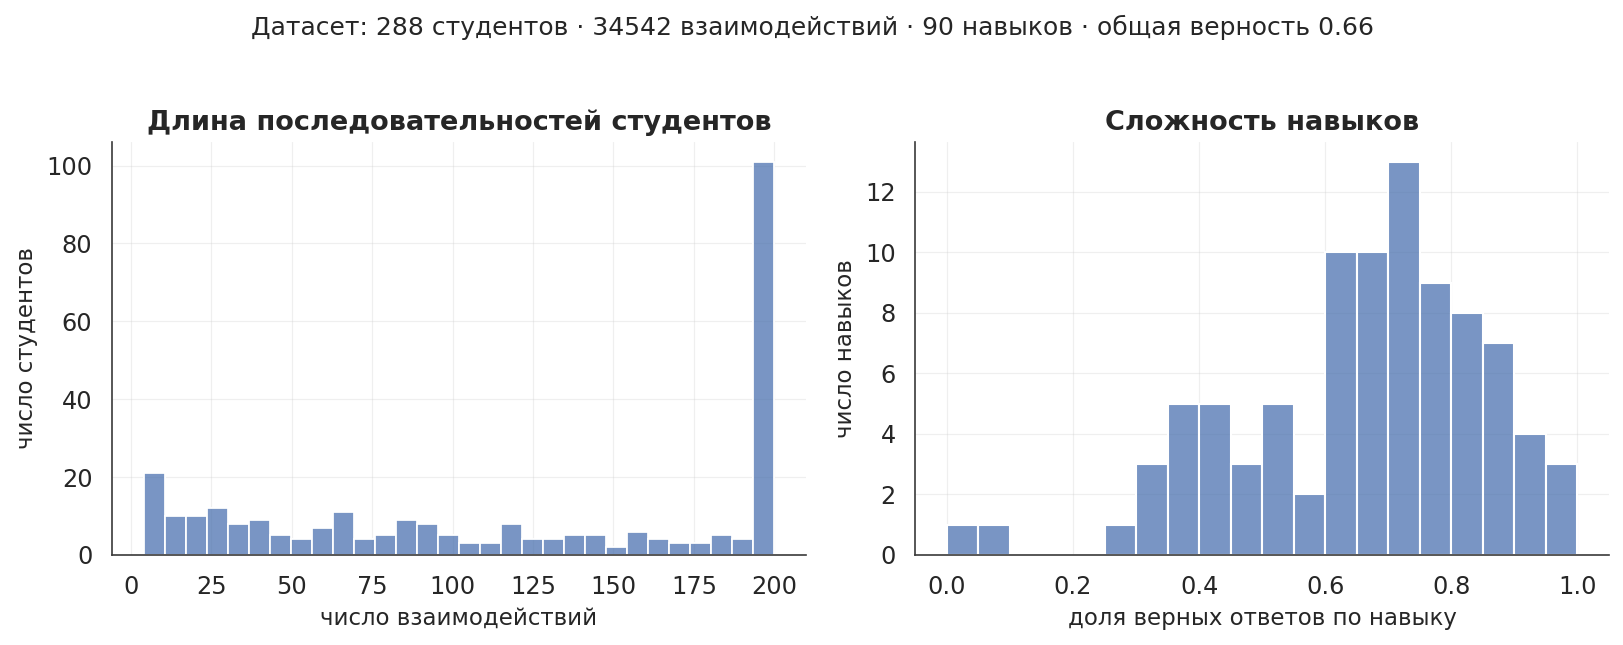

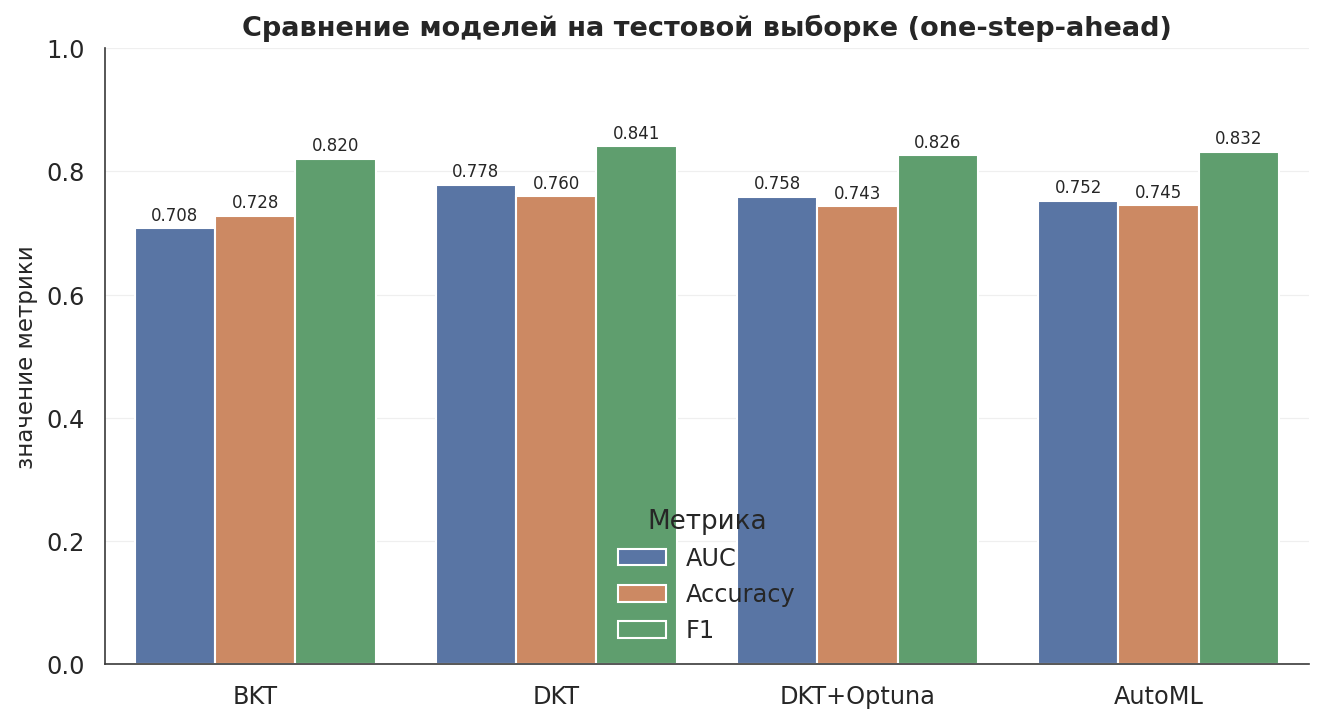

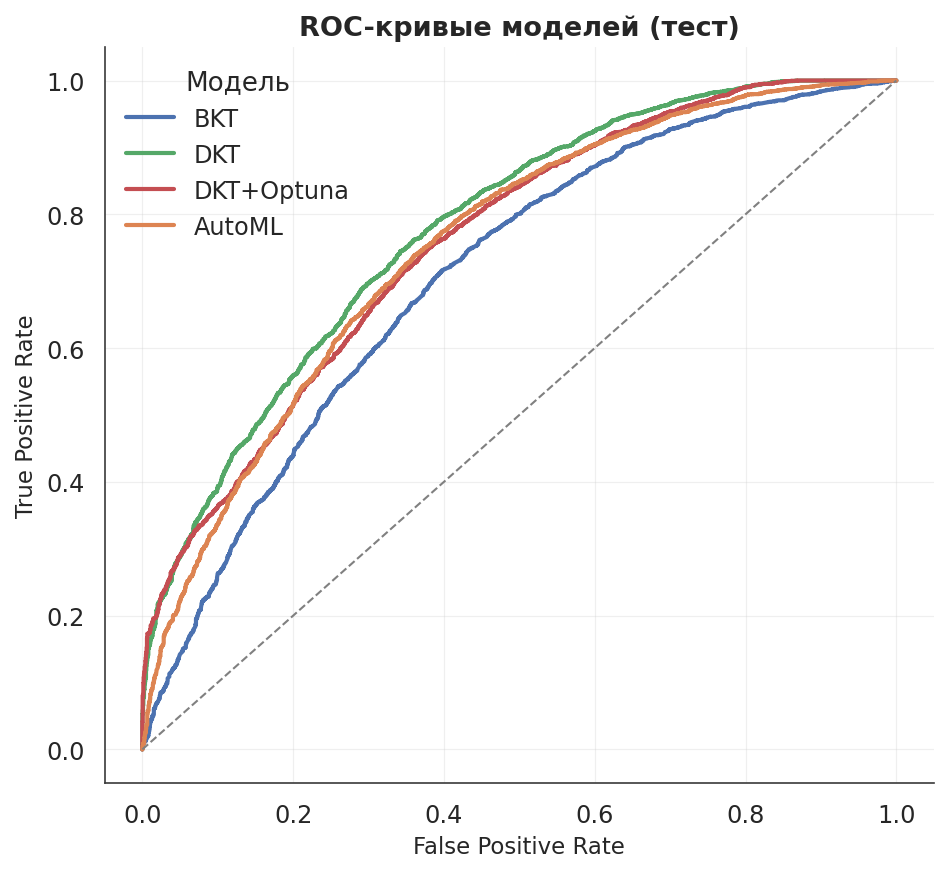

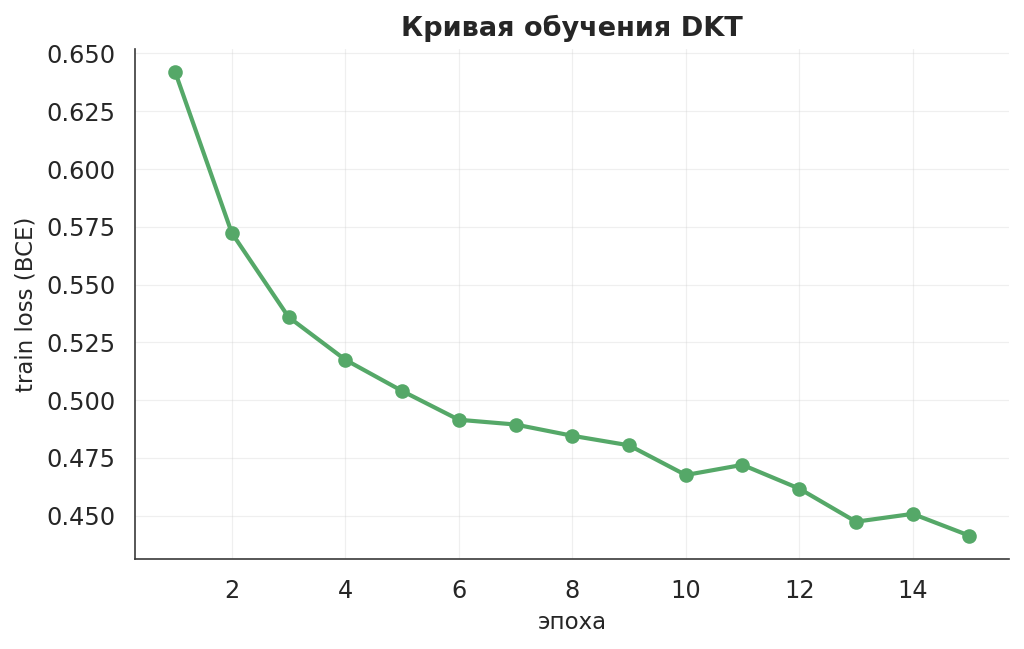

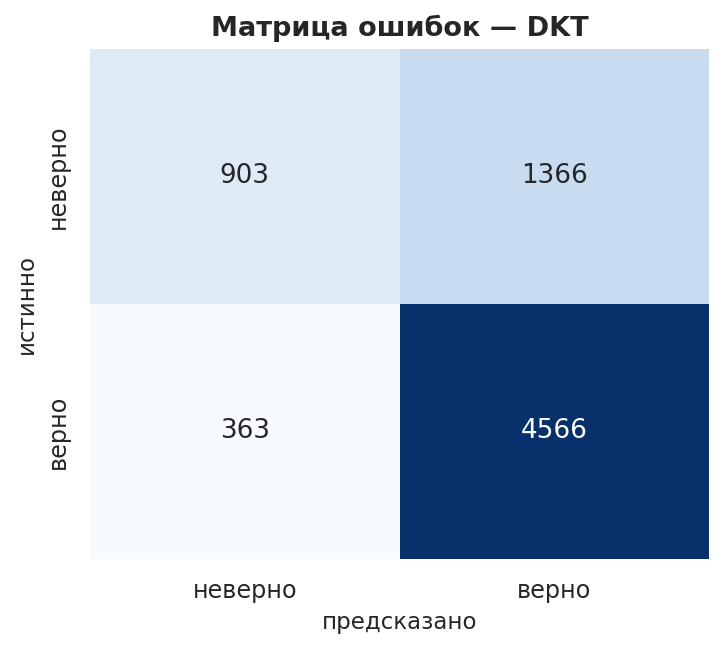

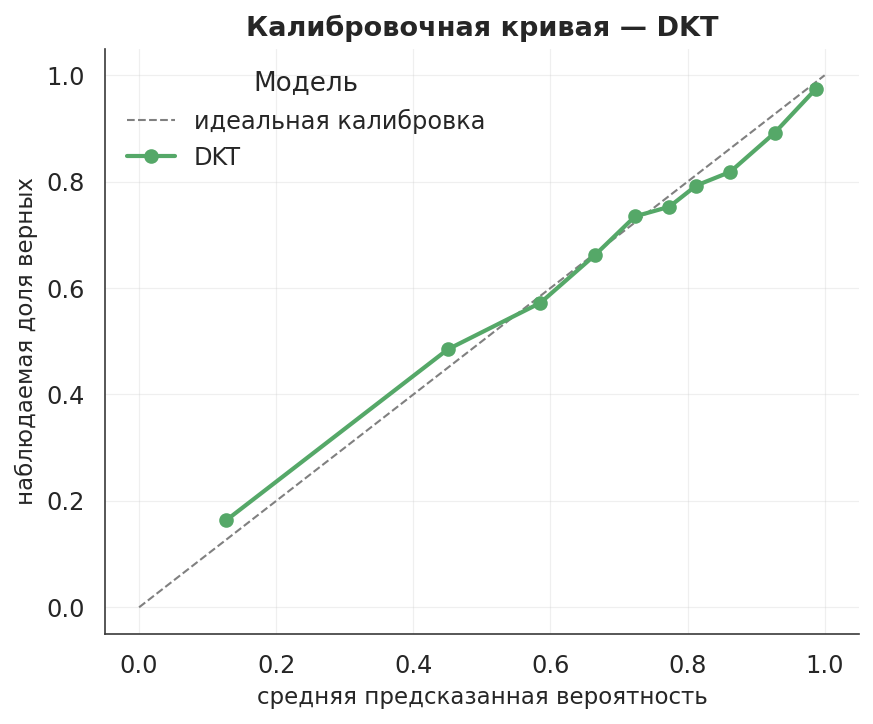

In [12]:
from src.evaluation import visualize as viz
from IPython.display import Image, display

viz.plot_dataset_overview(processed.long, processed.stats, cfg)
viz.plot_model_comparison(results, cfg)
viz.plot_roc(preds, cfg)
viz.plot_dkt_loss(losses, cfg)
best = max(results, key=lambda k: results[k]['auc'])
viz.plot_confusion(*preds[best], best, cfg)
viz.plot_calibration(*preds[best], best, cfg)
for f in ['dataset_overview', 'model_comparison', 'roc_comparison', 'dkt_loss', 'confusion_matrix', 'calibration']:
    display(Image(f'reports/figures/{f}.png'))

## 6. Окончательное обучение одной командой (+ логирование в MLflow)

Запускает весь пайплайн целиком и пишет метрики/артефакты в MLflow и `reports/`.
Для финального прогона поставьте `data_source='full'`. Бюджеты обучения
(эпохи, число trials Optuna, время FLAML) настраиваются в `config/config.yaml`.

In [13]:
from src.pipeline import run

summary = run('config/config.yaml', data_source='full')   # окончательное обучение
summary['results']

13:37:32 | INFO    | kt-pipeline | Downloading https://raw.githubusercontent.com/jennyzhang0215/DKVMN/master/data/assist2009_updated/assist2009_updated_train.csv -> /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/data/raw/assist2009_train.csv
13:37:35 | INFO    | kt-pipeline | Downloading https://raw.githubusercontent.com/jennyzhang0215/DKVMN/master/data/assist2009_updated/assist2009_updated_test.csv -> /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/data/raw/assist2009_test.csv
13:37:37 | INFO    | kt-pipeline | Extracted 325637 interactions from 4151 students (110 skills).
13:37:38 | INFO    | kt-pipeline | Transform complete: {'n_interactions': 215673, 'n_students': 3862, 'n_skills': 109, 'global_correct_rate': 0.6351, 'split_students': {'train': 2704, 'val': 386, 'test': 772}, 'split_interactions': {'train': 150517, 'val': 19803, 'test': 45353}}
13:37:38 | INFO    | kt-pipeline | Loaded processed artifacts into /Users/grigorevaekaterina/Downloads

{'BKT': {'auc': 0.7200150233237881,
  'accuracy': 0.7046281392631139,
  'f1': 0.7888398486759143,
  'precision': 0.7228031659830146,
  'recall': 0.8681562695163417,
  'rmse': 0.443961060608908,
  'log_loss': 0.5790837544389619,
  'n': 45353},
 'DKT': {'auc': 0.811176576908427,
  'accuracy': 0.7562414481505574,
  'f1': 0.8228485727792902,
  'precision': 0.7658089573977425,
  'recall': 0.88906894000775,
  'rmse': 0.4054470739602445,
  'log_loss': 0.49128100384032447,
  'n': 44581},
 'DKT+Optuna': {'auc': 0.8163028314796837,
  'accuracy': 0.7606828020905767,
  'f1': 0.8261613413064377,
  'precision': 0.7685684835991027,
  'recall': 0.893084862789305,
  'rmse': 0.40189706486110316,
  'log_loss': 0.48162871806585966,
  'n': 44581},
 'AutoML': {'auc': 0.7879150629332818,
  'accuracy': 0.7433466363856857,
  'f1': 0.815255689934292,
  'precision': 0.7513164053358297,
  'recall': 0.8910901394767886,
  'rmse': 0.41625656353542095,
  'log_loss': 0.5184729631176807,
  'n': 45353}}

In [14]:
# Просмотр экспериментов:  в терминале -> mlflow ui --backend-store-uri file:./mlruns --port 5000
# затем открыть http://localhost:5000

## 7. Презентация (5–7 слайдов)

In [15]:
from src.presentation.build_deck import build
build()   # -> presentation/presentation.pptx

13:42:04 | INFO    | kt-pipeline | Presentation saved -> /Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/presentation/presentation.pptx (6 slides)


'/Users/grigorevaekaterina/Downloads/ml-pipeline-knowledge-tracing/presentation/presentation.pptx'